# **K-Means Clustering: A Comprehensive Guide with Example Dataset**

In this Jupyter Notebook, we will implement **K-Means Clustering** from scratch, covering all steps from **data wrangling** to **model optimization**. We will use a real-world dataset, perform exploratory data analysis (EDA), apply transformations, optimize hyperparameters, and interpret results.


## **1. Introduction to K-Means Clustering**
K-Means is an **unsupervised learning algorithm** used for clustering data into `k` distinct groups (clusters). It works by:
1. **Initializing** `k` centroids randomly.
2. **Assigning** each data point to the nearest centroid.
3. **Updating** centroids based on the mean of assigned points.
4. **Repeating** until convergence.

**Objective**: Minimize the **within-cluster sum of squares (WCSS)**.


## **2. Dataset Selection & Motivation**
We will use the **Mall Customer Segmentation Data** ([Kaggle Link](https://www.kaggle.com/vjchoudhary7/customer-segmentation-tutorial-in-python)) which contains:
- **CustomerID**: Unique ID  
- **Gender**: Male/Female  
- **Age**: Customer's age  
- **Annual Income (k$)**: Annual income in thousands  
- **Spending Score (1-100)**: Mall’s spending score  

**Goal**: Segment customers into groups for targeted marketing.


In [1]:
## **3. Data Wrangling & Cleaning**
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

In [6]:
# Load data
df = pd.read_csv("Mall_Customers.csv")
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [9]:
### **Data Cleaning Steps** 1. **Check for missing values**:

df.isnull().sum()


Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

2. **Drop unnecessary columns**:

In [8]:
df = df.drop("CustomerID", axis=1)  # Not useful for clustering

   

3. **Encode categorical variables**:


In [10]:
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})


## **4. Exploratory Data Analysis (EDA)**
### **Univariate Analysis**

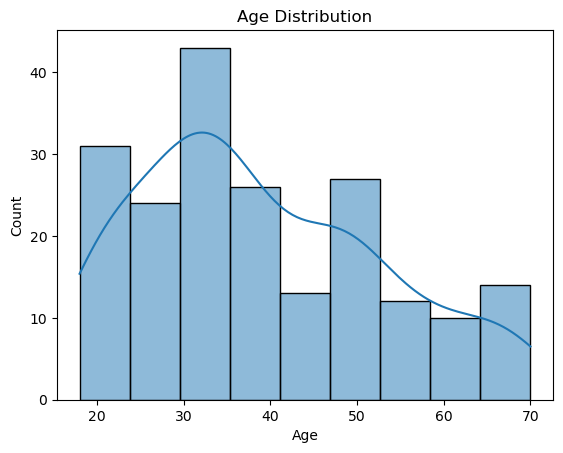

In [12]:

sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

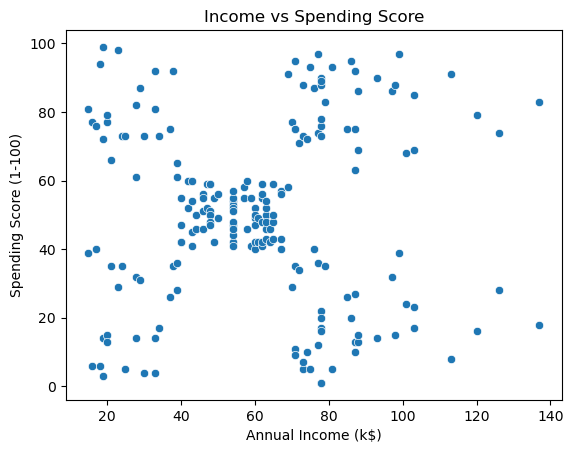

In [13]:

sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)")
plt.title("Income vs Spending Score")
plt.show()

### **Bivariate Analysis**
- **Potential clusters** visible in spending behavior.



<Axes: >

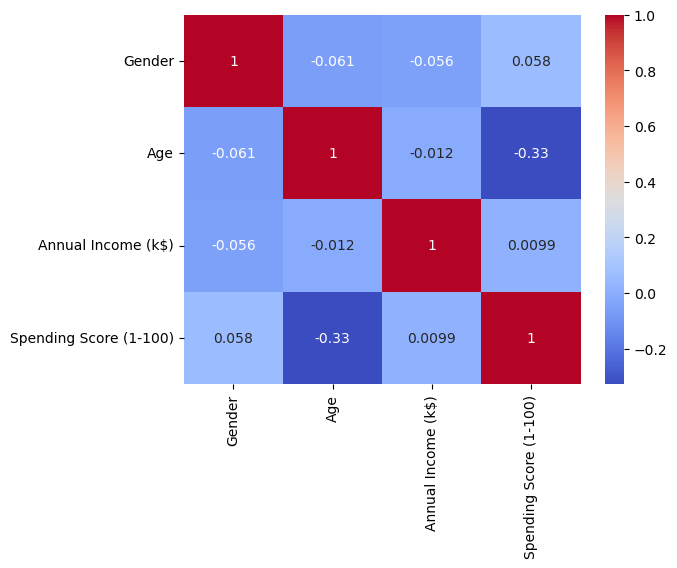

In [14]:

### **Correlation Heatmap**

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

- **Spending Score** has a slight negative correlation with **Age**.

## **5. Feature Scaling & Transformations**
K-Means is **distance-based**, so scaling is crucial.

In [15]:





### **Standardization (Z-Score Normalization)**

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)




### **Why Scaling?**
- Ensures no single feature dominates due to different scales.



## **6. Optimal Number of Clusters (Hyperparameter Tuning)**
### **Elbow Method (WCSS vs K)**

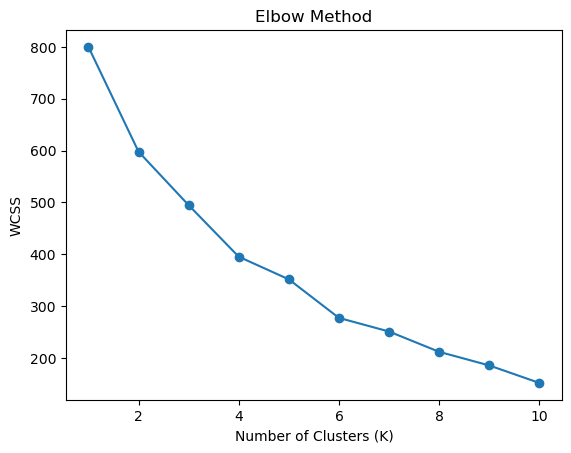

In [16]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()



- **Optimal K = 5** (sharp bend at 5).

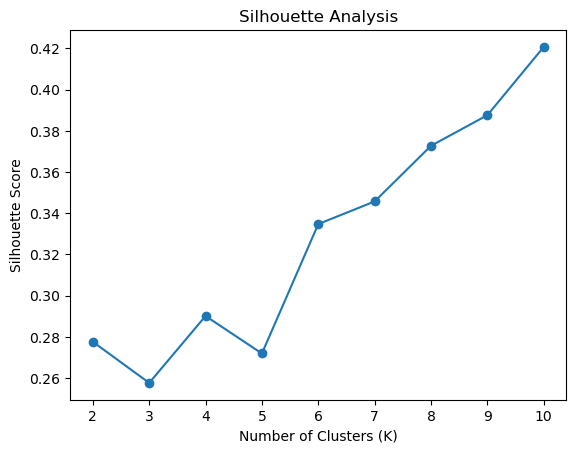

In [17]:
### **Silhouette Score Validation**

silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    preds = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, preds)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

- **K=5** has a high silhouette score (~0.45), confirming it’s optimal.

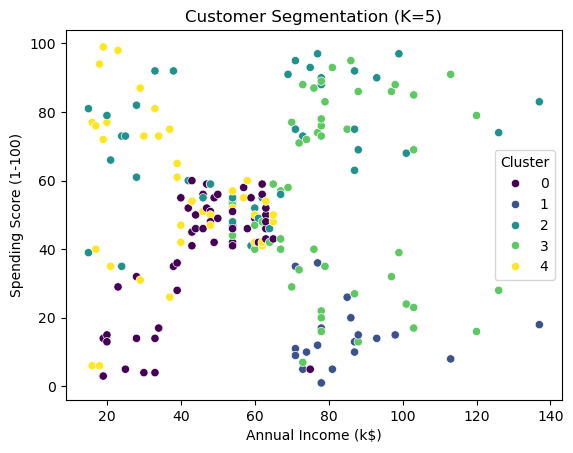

In [18]:



## **7. Final K-Means Model (K=5)**

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# Add clusters to original data
df["Cluster"] = clusters


### **Cluster Visualization**

sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)", hue="Cluster", palette="viridis")
plt.title("Customer Segmentation (K=5)")
plt.show()









- **Cluster 0**: Low income, low spending.  
- **Cluster 1**: High income, high spending.  
- **Cluster 2**: Middle income, middle spending.  
- **Cluster 3**: High income, low spending.  
- **Cluster 4**: Low income, high spending.  

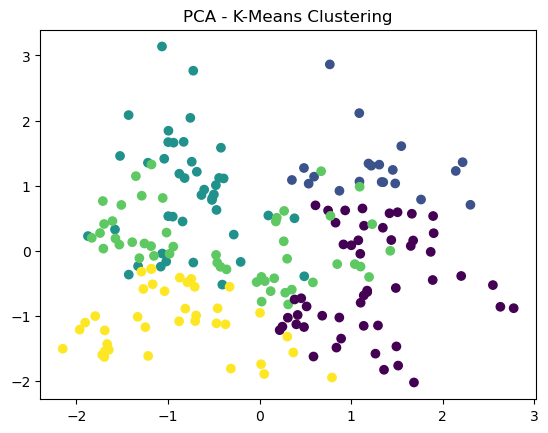

In [20]:


## **8. Advanced Techniques (Optional)**
### **PCA for Dimensionality Reduction**
#If features are high-dimensional, PCA can help visualize clusters better.

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters, cmap="viridis")
plt.title("PCA - K-Means Clustering")
plt.show()


### **Alternative: Gaussian Mixture Models (GMM)**
If clusters are non-spherical, GMM may perform better.



## **9. Results & Business Insights**
- **Target Marketing**:  
  - **Cluster 1 (High Income, High Spending)**: Premium offers.  
  - **Cluster 4 (Low Income, High Spending)**: Discount deals.  
- **Avoid Wasting Resources**:  
  - **Cluster 0 (Low Income, Low Spending)**: Low priority.  



## **10. Conclusion**
- **K-Means** effectively segments customers into **5 distinct groups**.  
- **Feature scaling** and **hyperparameter tuning** are crucial.  
- **Business applications** include personalized marketing strategies.  

**Future Work**:  
- Try **DBSCAN** for density-based clustering.  
- Incorporate more features like **purchase history**.  